In [6]:
import math
from urllib.request import urlopen, Request

import matplotlib as mpl
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

from mplsoccer import VerticalPitch, Sbopen, FontManager, inset_image

# data parser, fonts and path effects for giving the font an edge
parser = Sbopen()
roboto_bold = FontManager(
    'https://raw.githubusercontent.com/google/fonts/main/apache/robotoslab/RobotoSlab%5Bwght%5D.ttf')
path_eff = [path_effects.Stroke(linewidth=3, foreground='white'),
            path_effects.Normal()]

In [15]:
Belgium_player_data = pd.DataFrame(
    {
        'position': ['GK','CB','CB','CB','RWB','LWB','CM','CM','AM','AM','ST'],
        'position_id': [1, 2, 5, 6, 3, 4, 7, 8, 10, 9, 11],
        'player': ['Courtois','Alderweireld','Vertonghen','Castagne','Thomas Meunier',
                   'Thorgan Hazard','Onana','Witsel','Kevin De Bruyne','Hazard','Michy Batshuayi'],
        'score': [4.5, 6.0, 6.6, 6.1, 6.7, 6.9, 6.6, 6.6, 6.5, 6.4, 5.9],  # ← removed extra ]
        'team': ['Belgium'] * 11
    }
)

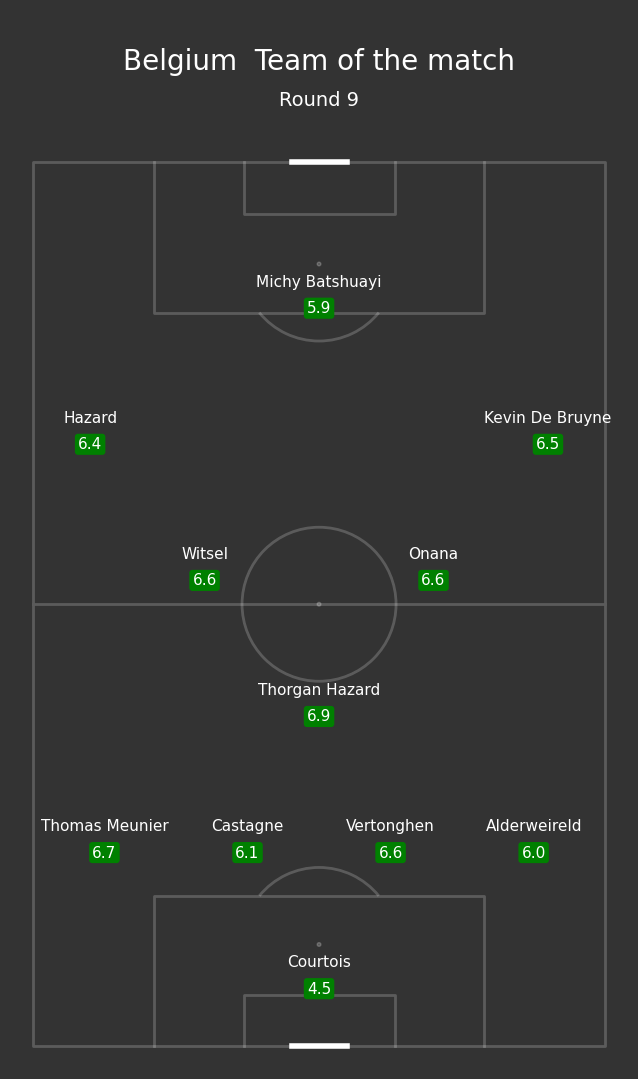

In [16]:
mplsoccer_433_positions = [1, 2, 5, 6, 3, 4, 7, 8, 10, 11, 9]
Belgium_player_data['mpl_position_id'] = mplsoccer_433_positions  # ← was morocco_player_data

pitch = VerticalPitch(pitch_type='opta', pitch_color='#333333', line_color='white', line_alpha=0.2,
                      line_zorder=3)
fig, axes = pitch.grid(endnote_height=0, figheight=13, title_height=0.1, title_space=0, space=0)
fig.set_facecolor('#333333')

axes['title'].axis('off')
axes['title'].text(0.5, 0.6, 'Belgium  Team of the match', ha='center', va='center', color='white',
                   fontsize=20)
axes['title'].text(0.5, 0.3, 'Round 9', ha='center', va='center', color='white', fontsize=14)

text_names = pitch.formation('433', kind='text', positions=Belgium_player_data.mpl_position_id,
                             text=Belgium_player_data.player, ax=axes['pitch'],
                             xoffset=-2,
                             ha='center', va='center', color='white', fontsize=11)

text_scores = pitch.formation('433', kind='text', positions=Belgium_player_data.mpl_position_id,
                              text=Belgium_player_data.score, ax=axes['pitch'],
                              xoffset=-5,
                              ha='center', va='center', color='white', fontsize=11,
                              bbox=dict(facecolor='green', boxstyle='round,pad=0.2', linewidth=0))